© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# **Vak Kurátor (SOLUTION)**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Nyári Diákolimpia, Tábor Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Active Learning: Solution Notebook</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>40 pont (4 × 10)</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2026. június</span>
  </div>
</div>

<br>

> **Figyelem:** ez a notebook a **szervezői/oktatási referencia** változat. A cellák a teszthalmaz címkéit, a zaj- és elterelőmaszkokat, valamint a publikus/privát szétválasztást is használják. Ezek **nem érhetők el** a versenyzői (RAW) notebookban. A célja, hogy bemutassa, hogyan reprodukálható helyben a kiértékelő, és hogy különböző stratégiákat egymás mellé állítva taníthassa az aktív tanulás tradeoffjait.

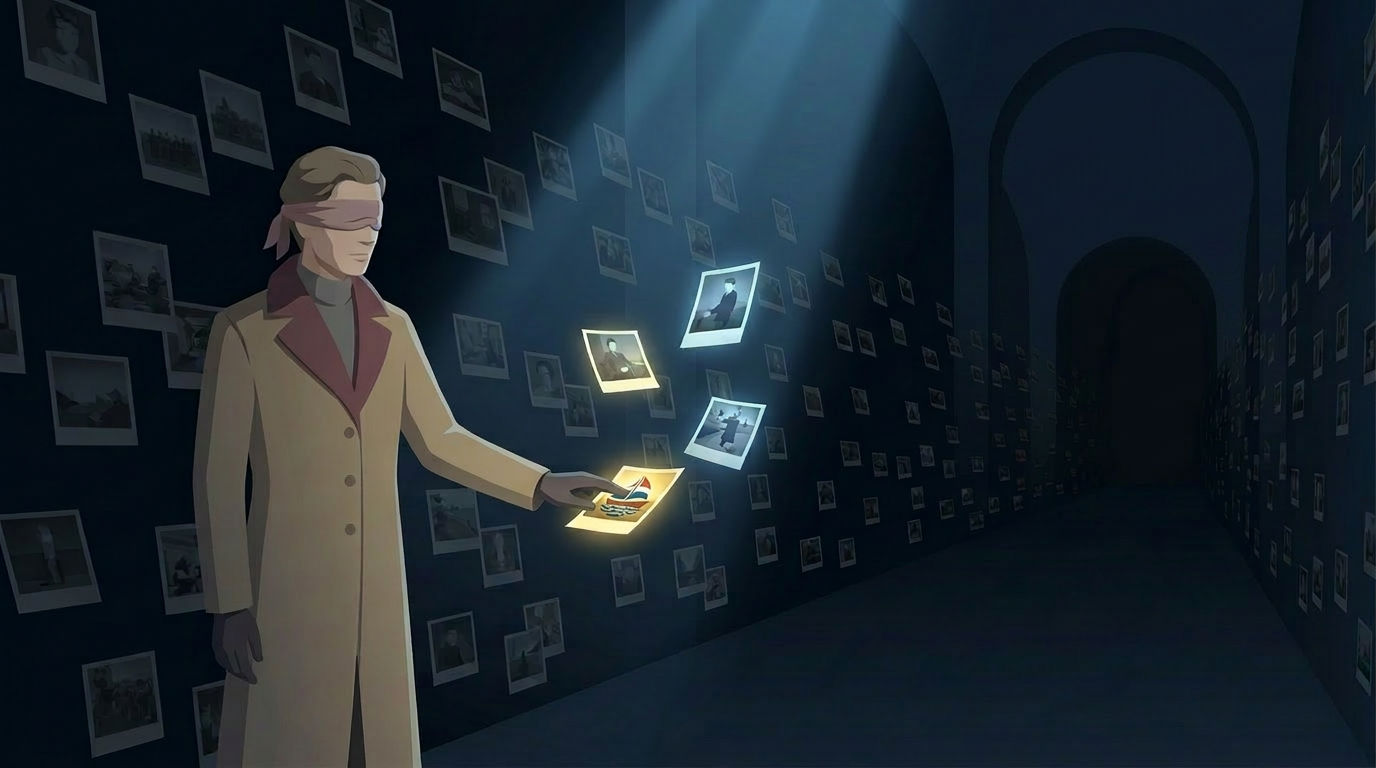

## **Beállítások és importok**

Rögzített random seed a reprodukálhatóságért. A megoldás során ugyanezt a seedet használjuk, hogy a stratégiák összehasonlítása stabil maradjon.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# NE MÓDOSÍTSD — ezzel a seeddel kapod ugyanazt a submission CSV-t
# minden újrafuttatáskor. A szerver determinisztikus.
# ═══════════════════════════════════════════════════════════════════
import os
import subprocess
import sys
import json
import random
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import zipfile
import io
from PIL import Image

# --- Reprodukálhatóság: minden véletlent egyetlen seedhez kötünk ---
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)   # set/dict iteration order, gyermek folyamatoknak
random.seed(SEED)                          # stdlib random
np.random.seed(SEED)                       # numpy globális RNG

# Opcionális: ha torch-ot is használsz, ott is rögzítjük
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# --- Konstansok (a kiértékelővel egyeznek) ---
POOL_SIZE  = 15_000
TEST_SIZE  =  5_000
N_CLASSES  =     50
BUDGET     =    300
EMB_DIM    =    384

## **Adathalmaz letöltése (privilegizált)**

A referencia megoldás 11 artefaktumot használ (a versenyző csak az első négy­et látja):

| fájl | mit tartalmaz | versenyző látja? |
|------|---------------|:---:|
| `pool_emb.npy`         | (15000, 384) DINOv2 beágyazási vektorok | ✓ |
| `pool_thumbs.zip`      | 15000 db 32×32 miniatűr | ✓ |
| `seed_emb.npy`         | (200, 384) seed beágyazás | ✓ |
| `seed_labels.npy`      | (200,) seed címkék | ✓ |
| `pool_labels.npy`      | (15000,) **megfigyelt** címkék (8% zajos) | – |
| `pool_true_labels.npy` | (15000,) **valódi** címkék | – |
| `pool_is_noisy.npy`    | (15000,) bool, zajos-e | – |
| `pool_is_distractor.npy` | (15000,) bool, elterelő-e | – |
| `test_emb.npy`         | (5000, 384) teszt beágyazás | – |
| `test_labels.npy`      | (5000,) teszt címkék | – |
| `hard_mask.npy`        | (5000,) bool, az `al_s4` szelet | – |
| `test_public_mask.npy` | (5000,) bool, publikus 30% | – |

Az alábbi cella biztonságosan fut Google Colabban és lokálisan is. Ha `gdown` nincs telepítve, automatikusan telepíti; ha sikertelen, kiírja a manuális letöltési URL-eket. Ha a fájl már a munkamappában van, átugorja. Cseréld le a `<*_FILE_ID>` placeholdereket a Drive-on lévő fájlok azonosítóira.

In [2]:
FILES = {
    "pool_emb.npy":         "1wqtCW6KwjVCaqnT7Ycy6EmgP1EAXN25U",
    "pool_thumbs.zip":      "1QDEhMHk-L1PtfliEGxdz3EPavDI-jXEm",
    "seed_emb.npy":         "1hn5WDIMQ-CfiiDoFDD0V8uEMbqS40FUz",
    "seed_labels.npy":      "14mmvPJSt0POPx0GVpFxqpV_XMmR2AvoS",
    "pool_labels.npy":      "18GIsihbMzmgAJlknFjOtm2SdL0KB4wqv",
    "pool_true_labels.npy": "1i4ekmLh6GCy0AvsUxiwEhwF00K6tcD-O",
    "pool_is_noisy.npy":    "1InrURBGVAyI-iO5WQ9-OHjTLlXS0iNWx",
    "pool_is_distractor.npy": "1uS8iX30qoXXz-RveZ4CwMtahYUFQ2HrE",
    "test_emb.npy":         "19BgWnAmPx2ktXsl2usVsJ4_CCErE3OhV",
    "test_labels.npy":      "1C5iqpcONp-nq3WBR_yXE9x1u-0ySo-TZ",
    "hard_mask.npy":        "1wQQYfwrLiYx58kBssBYQx3-R2oa0PrDw",
    "test_public_mask.npy": "1A3hPkAIl2OrbrqVRhOSpJdg02LRFbIEA",
    "visible_to_coarse.npy": "1u_QmS3MO03sVMP9r3_zkteMY2AuovcYf",   # testvér-tudatos confusable-rare 
    "class_mapping.json":     "1cXYTd79JOZkwH1zjkZ8fo7faTHdmBeIx",   # local idx -> CIFAR-100 fine id
}

missing = [name for name in FILES if not os.path.exists(name)]

if not missing:
    print("Minden fájl megvan a munkamappában, letöltés kihagyva.")
else:
    try:
        import gdown  # type: ignore
    except ImportError:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown  # type: ignore
        except Exception:
            gdown = None  # type: ignore

    if gdown is None:
        print("gdown nem elérhető. Töltsd le kézzel a következő fájlokat a munkamappába:\n")
        for name in missing:
            print(f"  https://drive.google.com/uc?id={FILES[name]}  ->  {name}")
    else:
        for name in missing:
            file_id = FILES[name]
            try:
                gdown.download(id=file_id, output=name, quiet=False)
            except Exception as e:
                print(f"  {name} letöltése sikertelen: {e}")
                print(f"  manuális letöltés: https://drive.google.com/uc?id={file_id}")

Minden fájl megvan a munkamappában, letöltés kihagyva.


## **Adatok betöltése**

A letöltött fájlokat numpy tömbökbe olvassuk be, a kiértékelőhöz illeszkedő dtype-okkal. A `rare_classes` listát származtatjuk: a 5 legritkább olyan látható osztály a valódi címkék alapján (elterelők kihagyva), amelynek van legalább egy testvére a látható osztályok között (azonos CIFAR-100 szuperosztály-családban). Ez a **sibling-aware confusable-rare** halmaz, pontosan ezt teszi a szerver is: a `pool_class_counts.json` egy `{class_counts, rare_classes}` szótár, és a notebook itt ugyanazt az algoritmust futtatja le.

In [3]:
d = {
    "pool_emb":     np.load("pool_emb.npy").astype(np.float32),
    "pool_lbl":     np.load("pool_labels.npy").astype(np.int64),       # observed (with noise)
    "pool_true":    np.load("pool_true_labels.npy").astype(np.int64),  # private
    "pool_noisy":   np.load("pool_is_noisy.npy").astype(bool),
    "pool_distr":   np.load("pool_is_distractor.npy").astype(bool),
    "seed_emb":     np.load("seed_emb.npy").astype(np.float32),
    "seed_lbl":     np.load("seed_labels.npy").astype(np.int64),
    "test_emb":     np.load("test_emb.npy").astype(np.float32),
    "test_lbl":     np.load("test_labels.npy").astype(np.int64),
    "test_hard":    np.load("hard_mask.npy").astype(bool),
    "test_public":  np.load("test_public_mask.npy").astype(bool),
    # per-new-class CIFAR-100 superclass id, used for sibling-aware confusable-rare
    "visible_coarse": np.load("visible_to_coarse.npy").astype(np.int32),
}

pool_visible = ~d["pool_distr"]
counts = np.array([((d["pool_true"] == c) & pool_visible).sum() for c in range(N_CLASSES)])

# Sibling-aware confusable-rare: bottom-5 visible classes by raw count, AMONG those
# whose CIFAR-100 superclass has at least one OTHER visible class. Identical algorithm
# to the server (see evaluate-submission/index.ts → deriveConfusableRare).
sc_to_classes = {}
for c in range(N_CLASSES):
    sc_to_classes.setdefault(int(d["visible_coarse"][c]), []).append(c)
has_siblings = [c for c in range(N_CLASSES)
                if len(sc_to_classes[int(d["visible_coarse"][c])]) >= 2]
d["rare_classes"] = sorted(has_siblings, key=lambda c: int(counts[c]))[:5]
if len(d["rare_classes"]) < 5:
    remaining = sorted([c for c in range(N_CLASSES) if c not in d["rare_classes"]],
                       key=lambda c: int(counts[c]))
    d["rare_classes"] = list(d["rare_classes"]) + remaining[:5 - len(d["rare_classes"])]

print(f"pool: {d['pool_emb'].shape},  test: {d['test_emb'].shape}")
print(f"zajos pool elem: {d['pool_noisy'].sum()} ({100*d['pool_noisy'].mean():.1f}%)")
print(f"elterelő pool elem: {d['pool_distr'].sum()} ({100*d['pool_distr'].mean():.1f}%)")
print(f"hard test szelet: {d['test_hard'].sum()} elem")
print(f"public/private test szétválasztás: {d['test_public'].sum()} / {(~d['test_public']).sum()}")
print(f"5 confusable-rare osztály (al_s2): {d['rare_classes']}")
print(f"  coarse labels: {[int(d['visible_coarse'][c]) for c in d['rare_classes']]}")

pool: (15000, 384),  test: (5000, 384)
zajos pool elem: 1152 (7.7%)
elterelő pool elem: 600 (4.0%)
hard test szelet: 1000 elem
public/private test szétválasztás: 1500 / 3500
5 confusable-rare osztály (al_s2): [1, 2, 3, 4, 7]
  coarse labels: [14, 8, 6, 7, 18]


## **Adatfeltárás: mit tartalmaz az adat?**

Stratégiaválasztás előtt nézzük meg, hogyan néznek ki a confusable-rare osztályok, és milyen a 384 dimenziós DINOv2 beágyazási tér a zajos és elterelő pontokkal. Ez a két nézet motiválja a lenti stratégiákat.

In [4]:
# CIFAR-100 fine osztálynevek; a látható (0..49) indexekhez a class_mapping.json
# alapján rendeljük hozzá. Ha a fájl nincs letöltve, a vizualizáció "ID <n>"-t ír.
CIFAR100_FINE = ['apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle',
    'bicycle','bottle','bowl','boy','bridge','bus','butterfly','camel','can','castle',
    'caterpillar','cattle','chair','chimpanzee','clock','cloud','cockroach','couch','crab',
    'crocodile','cup','dinosaur','dolphin','elephant','flatfish','forest','fox','girl',
    'hamster','house','kangaroo','keyboard','lamp','lawn_mower','leopard','lion','lizard',
    'lobster','man','maple_tree','motorcycle','mountain','mouse','mushroom','oak_tree',
    'orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree','plain','plate',
    'poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket','rose','sea','seal',
    'shark','shrew','skunk','skyscraper','snail','snake','spider','squirrel','streetcar',
    'sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor',
    'train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm']
try:
    _vis = json.load(open("class_mapping.json"))["visible_cifar_classes"]
    FINE_NAMES = {lid: CIFAR100_FINE[cid] for lid, cid in enumerate(_vis)}
except (FileNotFoundError, KeyError):
    FINE_NAMES = {}
print("FINE_NAMES:", len(FINE_NAMES), "osztálynév betöltve")

FINE_NAMES: 50 osztálynév betöltve


### A confusable-rare osztályok

Az `al_s2` axis a ritka, testvérosztállyal rendelkező osztályokat pontozza. Néhány mintakép osztályonként:

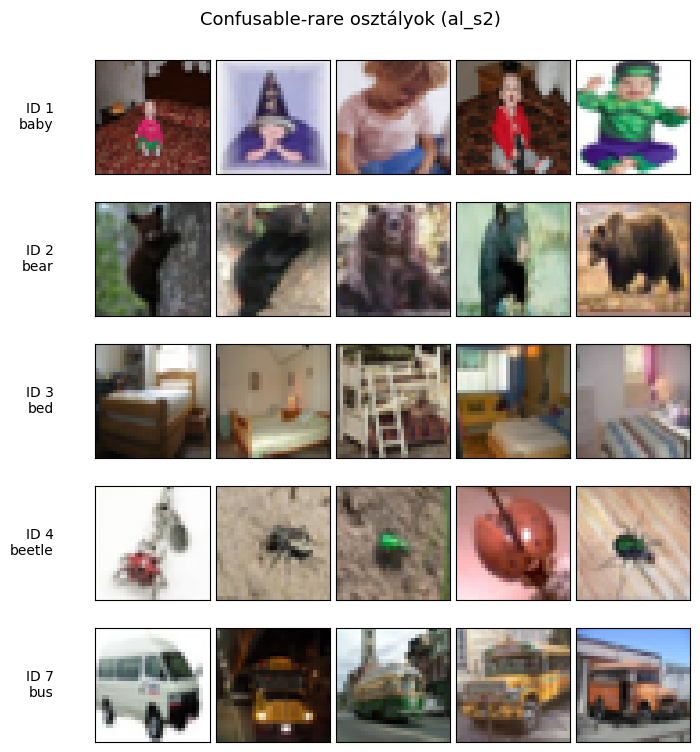

In [5]:
rare = d['rare_classes']
N_COL = 5
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(rare), N_COL, figsize=(1.7*N_COL, 1.7*len(rare)))
axes = np.atleast_2d(axes)
with zipfile.ZipFile("pool_thumbs.zip") as z:
    for r, c in enumerate(rare):
        idx = np.where((d['pool_true'] == c) & ~d['pool_distr'])[0]
        pick = rng.choice(idx, size=min(N_COL, len(idx)), replace=False)
        axes[r, 0].set_ylabel(f"ID {c}\n{FINE_NAMES.get(c, '')}", rotation=0,
                              ha='right', va='center', fontsize=10, labelpad=30)
        for j in range(N_COL):
            ax = axes[r, j]; ax.set_xticks([]); ax.set_yticks([])
            if j < len(pick):
                with z.open(f"{pick[j]:05d}.png") as f:
                    ax.imshow(Image.open(io.BytesIO(f.read())))
            else:
                ax.axis('off')
fig.suptitle("Confusable-rare osztályok (al_s2)", fontsize=13)
plt.subplots_adjust(left=0.2, hspace=0.1, wspace=0.05, top=0.93)
plt.show()

In [6]:
# Pontosan miért ezek a confusable-rare osztályok: RITKÁK (kevés pool-elem) ÉS van
# testvérük (azonos CIFAR-100 superclass másik látható osztálya), amivel a prototípus-
# modell könnyen összekeveri őket. A grid 5 osztálya NEM egymás testvére: mindegyik a
# SAJÁT testvérével téveszthető össze (ezért tűnik beetle és bus eltérőnek).
sc_to_classes = {}
for c in range(N_CLASSES):
    sc_to_classes.setdefault(int(d['visible_coarse'][c]), []).append(c)
visible = ~d['pool_distr']
cnt = lambda c: int(((d['pool_true'] == c) & visible).sum())

print(f"{'osztály':20}{'pool-elem':>10}   testvér(ek) az azonos superclassban [elemszám]")
print('-' * 84)
for c in d['rare_classes']:
    sc   = int(d['visible_coarse'][c])
    sibs = [s for s in sc_to_classes[sc] if s != c]
    sibs_str = ', '.join(f"{FINE_NAMES.get(s, 'ID '+str(s))} [{cnt(s)}]" for s in sibs) or '(nincs)'
    print(f"{FINE_NAMES.get(c,'')+f' (ID {c})':20}{cnt(c):>10}   {sibs_str}")

allc = sorted(cnt(c) for c in range(N_CLASSES))
print(f"\nElemszám-eloszlás az 50 osztályon: min {allc[0]}, medián {allc[len(allc)//2]}, max {allc[-1]}.")
print(f"A rare osztályok elemszáma {sorted(cnt(c) for c in d['rare_classes'])}: a legkisebbek, "
      f"de mind van legalább egy (gyakoribb) testvére, ezért 'confusable-rare'.")

osztály              pool-elem   testvér(ek) az azonos superclassban [elemszám]
------------------------------------------------------------------------------------
baby (ID 1)                 30   boy [460], girl [30], man [30]
bear (ID 2)                 30   wolf [460]
bed (ID 3)                  30   couch [460], wardrobe [460]
beetle (ID 4)               30   butterfly [30], cockroach [30]
bus (ID 7)                  30   motorcycle [460]

Elemszám-eloszlás az 50 osztályon: min 30, medián 460, max 460.
A rare osztályok elemszáma [30, 30, 30, 30, 30]: a legkisebbek, de mind van legalább egy (gyakoribb) testvére, ezért 'confusable-rare'.


**Megfigyelés.** A táblából látszik, *miért* pont ezek: a legkevesebb pool-elemmel rendelkező osztályok, amelyeknek van egy gyakoribb superclass-testvérük. A prototípus-modell ezért a testvér felé húzza őket – pont ezt a csapdát kezeli az **osztálybalansz** és a **sibling-tudatos** válogatás a lenti stratégiákban.

### A leggyakoribb osztályok (kontraszt)

A legnagyobb elemszámú osztályok: ezekből bőven van minta, a prototípusuk stabil. A confusable-rare osztályok épp az ellenkezője, ezért nehéz őket eltalálni a 300-as keretben.

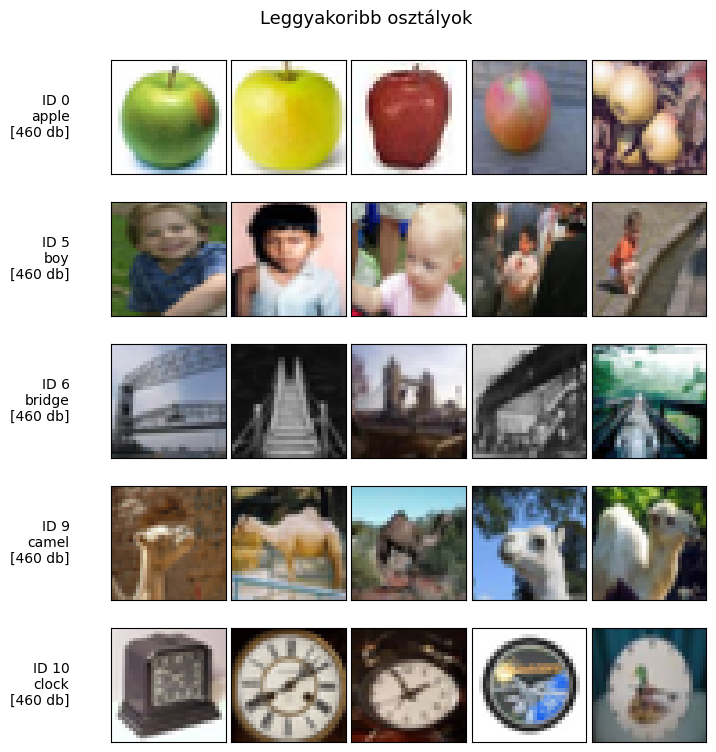

In [7]:
visible = ~d['pool_distr']
cnt = lambda c: int(((d['pool_true'] == c) & visible).sum())
common = sorted(range(N_CLASSES), key=cnt, reverse=True)[:5]

N_COL = 5
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(common), N_COL, figsize=(1.7*N_COL, 1.7*len(common)))
axes = np.atleast_2d(axes)
with zipfile.ZipFile("pool_thumbs.zip") as z:
    for r, c in enumerate(common):
        idx = np.where((d['pool_true'] == c) & visible)[0]
        pick = rng.choice(idx, size=min(N_COL, len(idx)), replace=False)
        axes[r, 0].set_ylabel(f"ID {c}\n{FINE_NAMES.get(c, '')}\n[{cnt(c)} db]", rotation=0,
                              ha='right', va='center', fontsize=10, labelpad=30)
        for j in range(N_COL):
            ax = axes[r, j]; ax.set_xticks([]); ax.set_yticks([])
            if j < len(pick):
                with z.open(f"{pick[j]:05d}.png") as f:
                    ax.imshow(Image.open(io.BytesIO(f.read())))
            else:
                ax.axis('off')
fig.suptitle("Leggyakoribb osztályok", fontsize=13)
plt.subplots_adjust(left=0.2, hspace=0.1, wspace=0.05, top=0.93)
plt.show()

### A beágyazási tér térképe (t-SNE)

A confusable-rare osztályok *megfigyelt* címkéjű pontjait 2D-be vetítjük, és kiemeljük a zajos címkéjű (rossz klaszterben ülő) és az elterelő pontokat: ezek a válogatás csapdái.

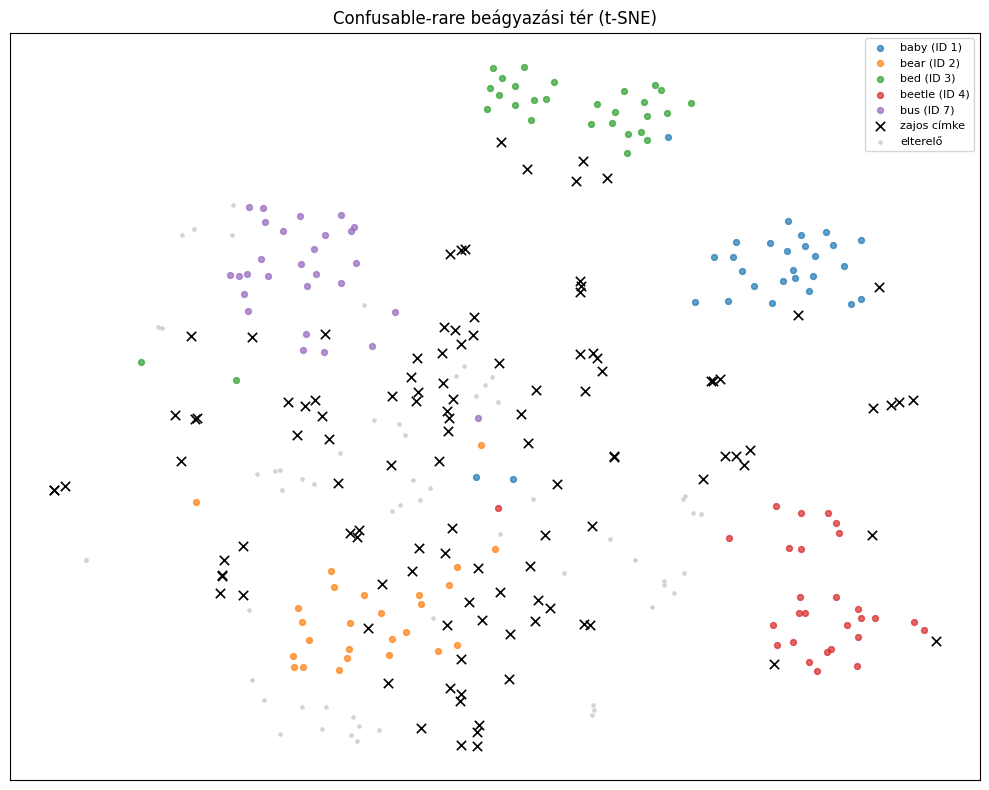

In [8]:
target = d['rare_classes']
idx = np.where(np.isin(d['pool_lbl'], target))[0]           # amit a versenyzo rare-kent LAT (megfigyelt cimke)
perp = max(5, min(30, len(idx)//4))
emb2d = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto',
             perplexity=perp).fit_transform(d['pool_emb'][idx])

obs   = d['pool_lbl'][idx]
noisy = d['pool_noisy'][idx]; distr = d['pool_distr'][idx]; clean = ~noisy & ~distr

plt.figure(figsize=(10, 8))
for c in target:
    m = clean & (obs == c)
    plt.scatter(emb2d[m,0], emb2d[m,1], s=18, alpha=.7, label=f"{FINE_NAMES.get(c, 'ID '+str(c))} (ID {c})")
plt.scatter(emb2d[noisy,0], emb2d[noisy,1], marker='x', c='black', s=45, lw=1.2, label='zajos címke')
plt.scatter(emb2d[distr,0], emb2d[distr,1], marker='.', c='lightgray', s=22, label='elterelő')
plt.legend(fontsize=8, loc='best'); plt.xticks([]); plt.yticks([])
plt.title('Confusable-rare beágyazási tér (t-SNE)')
plt.tight_layout(); plt.show()

**Megfigyelés.** A klaszterek átfednek (confusable osztályok), a zajos pontok idegen klaszterben ülnek, az elterelők szétszórtan. Innen jön a három stratégia-összetevő, amit lentebb építünk fel: **elterelő-szűrés**, **zaj-/címke-konzisztencia**, és **osztálybalansz + diverzitás**.

## **Miért nehéz a 4 tengelyt együtt optimalizálni?**

A négy axist (al_s1 általános, al_s2 confusable-rare, al_s3 tisztaság, al_s4 nehéz szelet) nem lehet egyszerre maxolni, mert az adat szerkezete egymásnak feszíti őket: ami az egyik célnak jó pont vagy osztály, az a másiknak rossz. Az alábbi három ábra ezt mutatja meg, tisztán az adatból (semmi stratégia).

### Az informatív pontok éppen a kockázatosak

A *margó* = a seed-prototípusokhoz vett két legjobb koszinusz-hasonlóság különbsége. A kis margó azt jelenti, hogy a pont egyik osztályhoz sem húz egyértelműen (határeset = informatív, ezt keresi az al_s1/al_s4). Az ábrán a kis-margós sávot (~0–0.1) az **elterelők** uralják: nincs valódi osztályuk, ezért sehová sem hasonlítanak igazán. A **zajos** pontok ellenben szétszórtak, sőt a nagy margós tartományban is megjelennek: az *igazi* osztályukban egyértelmű győztesük van, így a hibás címke geometriailag nem látszik. Tanulság: aki informatív (kis margós) pontokat szed az al_s1/al_s4-hez, az elterelőt halászik (rontja az al_s3-at). A zaj ezzel szemben külön, címke-szintű gond, amit szomszédság-konzisztenciával lehet megfogni.

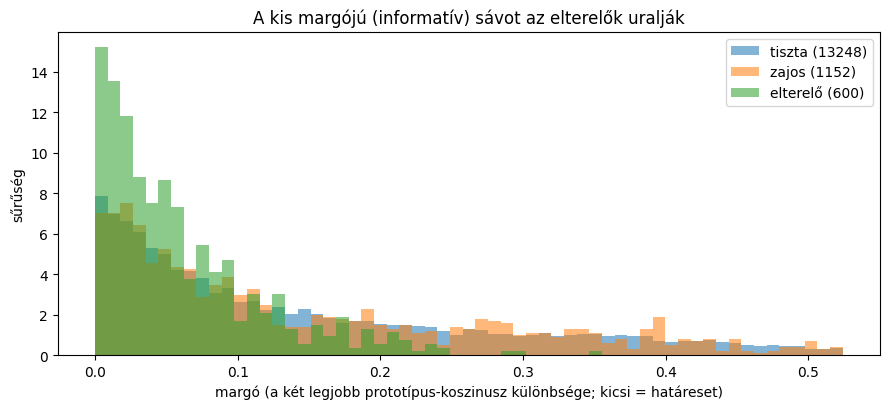

In [9]:
# seed prototípusok (L2-normált osztályközéppontok) és a pool margói
proto = np.zeros((N_CLASSES, EMB_DIM), dtype=np.float32)
for c in range(N_CLASSES):
    m = d['seed_lbl'] == c
    if m.sum(): proto[c] = d['seed_emb'][m].mean(0)
proto /= np.linalg.norm(proto, axis=1, keepdims=True) + 1e-12
pe = d['pool_emb'] / (np.linalg.norm(d['pool_emb'], axis=1, keepdims=True) + 1e-12)
sims = pe @ proto.T
top2 = np.partition(sims, -2, axis=1)[:, -2:]
margin = np.abs(top2[:, 1] - top2[:, 0])

clean = ~d['pool_noisy'] & ~d['pool_distr']
bins = np.linspace(0, np.percentile(margin, 99), 60)
plt.figure(figsize=(9, 4.2))
plt.hist(margin[clean],            bins=bins, density=True, alpha=.55, label=f"tiszta ({int(clean.sum())})")
plt.hist(margin[d['pool_noisy']],  bins=bins, density=True, alpha=.55, label=f"zajos ({int(d['pool_noisy'].sum())})")
plt.hist(margin[d['pool_distr']],  bins=bins, density=True, alpha=.55, label=f"elterelő ({int(d['pool_distr'].sum())})")
plt.xlabel('margó (a két legjobb prototípus-koszinusz különbsége; kicsi = határeset)')
plt.ylabel('sűrűség'); plt.legend()
plt.title('A kis margójú (informatív) sávot az elterelők uralják')
plt.tight_layout(); plt.show()

### Osztály-konfúziós mátrix

A seed osztály-prototípusok páronkénti koszinusz-hasonlósága, superclass szerint rendezve (az átló kifehérítve: az önhasonlóság = 1 elnyomná a skálát). A kép **nagyrészt sötét**, mert a legtöbb osztálypár jól elkülönül (~0.2 hasonlóság). A néhány **világos cella kis, 2-3 osztályos csomókban ül közvetlenül az átló mellett**: ezek a superclass-testvérek, amelyek erősen hasonlítanak (0.5-0.8). Az összekeverhetőség tehát **lokalizált**, csak néhány testvér-csomóra korlátozódik. Pont ezek a forró csomók adják az al_s2 nehézségét, miközben az osztályok többsége triviálisan szétválasztható.

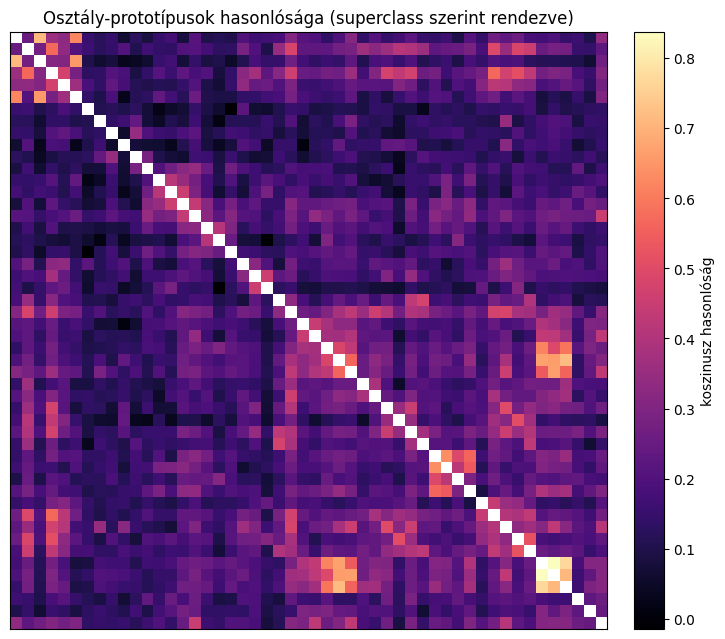

In [10]:
order = np.argsort(d['visible_coarse'])      # testvérek egymás mellé
S = proto[order] @ proto[order].T
np.fill_diagonal(S, np.nan)                  # az átló (önmaga = 1) elnyomná a skálát
plt.figure(figsize=(7.5, 6.5))
im = plt.imshow(S, cmap='magma', interpolation='nearest')
plt.colorbar(im, label='koszinusz hasonlóság', fraction=0.046, pad=0.04)
plt.xticks([]); plt.yticks([])
plt.title('Osztály-prototípusok hasonlósága (superclass szerint rendezve)')
plt.tight_layout(); plt.show()

### A megfigyelt címke megbízhatósága

Minden pool-pont koszinusz-hasonlósága a *megfigyelt* osztálya prototípusához. A **tiszta** pontok magasan ülnek (jellemzően 0.35–0.8): tényleg ott vannak, ahová a címkéjük mutat. A **zajos** és **elterelő** pontok viszont alacsonyan tornyosulnak (~0.1–0.2), mert messze esnek a megfigyelt osztályuktól, így egy egyszerű küszöb a szennyeződés nagy részét kiszűri. A csapda a **0.25–0.35 átfedési zóna**: itt a legbizonytalanabb, egyben legértékesebb tiszta pontok keverednek a szennyeződéssel. Aki a tisztaságért (al_s3) agresszívan vág, pont ezeket az informatív tiszta pontokat (al_s1/al_s4) dobja el, ezért éri meg a durva küszöb helyett konzisztencia-alapú szűrés.

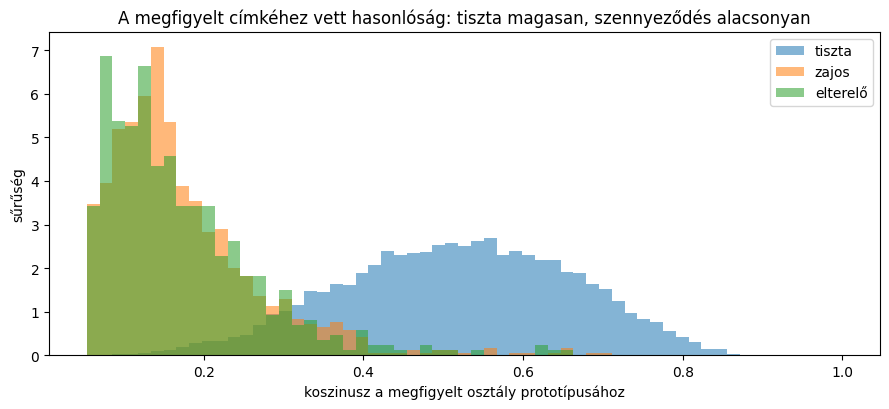

In [11]:
own = (pe * proto[d['pool_lbl']]).sum(1)     # koszinusz a MEGFIGYELT osztály prototípusához
bins = np.linspace(np.percentile(own, 1), 1, 60)
plt.figure(figsize=(9, 4.2))
plt.hist(own[clean],            bins=bins, density=True, alpha=.55, label='tiszta')
plt.hist(own[d['pool_noisy']],  bins=bins, density=True, alpha=.55, label='zajos')
plt.hist(own[d['pool_distr']],  bins=bins, density=True, alpha=.55, label='elterelő')
plt.xlabel('koszinusz a megfigyelt osztály prototípusához')
plt.ylabel('sűrűség'); plt.legend()
plt.title('A megfigyelt címkéhez vett hasonlóság: tiszta magasan, szennyeződés alacsonyan')
plt.tight_layout(); plt.show()

## **A kiértékelő reprodukciója**

A szerver (Deno edge function, `evaluate-submission/index.ts`) három lépésben dolgozik:

1. **Prototípus-középpontok**: a kiválasztott 300 index megfigyelt címkéiből osztályonként kiszámolja az átlagos beágyazási vektort, majd L2-normálja.
$$\boldsymbol{\mu}_c \;=\; \frac{\sum_{i \in S_c} \mathbf{e}_i}{\left\lVert \sum_{i \in S_c} \mathbf{e}_i \right\rVert_2}$$

2. **Predikció**: minden tesztképet a hozzá legközelebbi középponthoz tartozó osztályba sorol koszinusz-hasonlóság alapján.
$$\hat{y}_t \;=\; \arg\max_{c} \; \mathbf{e}_t^{\top} \boldsymbol{\mu}_c$$

3. **Pontok**: négy részpontot számol (al_s1, al_s2, al_s3, al_s4), részenként 10 pont a maximum.

Az alábbi két függvény pontosan ezt csinálja, numpy-ban.

In [12]:
def class_means(indices, pool_emb, pool_lbl):
    """L2-normált prototípus-középpontok osztályonként.
    Üres osztályoknak (nincs kiválasztott elem) zéró-vektor marad, a koszinusz
    hasonlóság rajtuk 0, így ezek az osztályok soha nem nyernek predikciót."""
    means = np.zeros((N_CLASSES, EMB_DIM), dtype=np.float32)
    for c in range(N_CLASSES):
        m = pool_lbl[indices] == c
        if m.sum() > 0:
            means[c] = pool_emb[indices[m]].mean(axis=0)
    norms = np.linalg.norm(means, axis=1, keepdims=True) + 1e-12
    return means / norms

def predict(test_emb, means_n):
    test_n = test_emb / (np.linalg.norm(test_emb, axis=1, keepdims=True) + 1e-12)
    return (test_n @ means_n.T).argmax(axis=1)

A scoring függvény mind a négy részpontot kiszámolja, és külön visszaadja a publikus, illetve a privát feléhez tartozó értéket. Az `al_s3` (distraktor-tisztaság) közvetlenül a kiválasztásból származik, nem teszt predikcióból, így nincs publikus/privát különbség. **FONTOS: az `al_s3` CSAK az elterelőket (OOD) bünteti, a címke-zajt NEM.** A zaj egyenletesen, véletlenszerűen, a kép változatlanul hagyásával kerül a megfigyelt címkékre, ezért nincs beágyazási nyoma, és a versenyző címke nélkül észlelhetetlen; az elterelők viszont alacsony centroid-hasonlóságnál ülnek, így embedding-alapon szűrhetők. A ~8% zaj benne marad a poolban (rontja a középpontokat, ha bekerül), de nem külön pontozott tengely.

A nyers értékre **küszöb-alapú görbét** alkalmazunk: minden részponthoz tartozik egy *floor* (e fölött kezd pontot adni a görbe) és egy *ceiling* (e fölött a teljes 10 pont jár). A görbe a random submissionöket alacsonyan tartja (~4/40 összpontszám), a tudatos stratégiákat egyértelműen jutalmazza. Az `AL_SCORING` floor és ceiling értékek **pontosan ugyanazok**, mint a szerveroldali kiértékelőben (`evaluate-submission/index.ts`), így a lokálisan számolt pontszám pontosan megegyezik azzal, amit a DOCK platform ad vissza.

In [13]:
# Pontozási görbe, pontosan ugyanaz, mint a szerveroldali kiértékelőben
# (evaluate-submission/index.ts → AL_SCORING). Kalibráció 2026-06-09:
# floor = empirikus random raw, ceiling = empirikus best honest raw per axis.
# FIGYELEM: az al_s3 mostantól CSAK a distraktor-tisztaságot pontozza; a
# címke-zaj NEM pontozott (a versenyző címke nélkül nem tudja észlelni). A lenti
# *_consistent / knn / oracle stratégiák a MEGFIGYELT címkét (pool_lbl) használják,
# amit a versenyző NEM kap meg — ezek csak privilegizált FELSŐ-KORLÁT referenciák,
# nem reprodukálható megoldások.
AL_SCORING = {
    # Kalibráció: floor = random raw, ceiling = best honest raw.
    # Random ≈ 0/40, oracle ≈ 37/40, single best honest ≈ 36/40,
    # per-axis-independent honest max = 40/40.
    # HONEST recalibráció (2026-06-25): a ceilingek a legjobb embedding-only raw
    # értékek (a korábbiak privilegizált, pool_lbl-t használó stratégiák voltak,
    # tisztességesen elérhetetlenek). Ablation: a pool_lbl-kapu törlése s1 0.717->0.688,
    # s2 0.740->0.586, s4 0.480->0.409.
    "al_s1": (0.498, 0.705),
    "al_s2": (0.078, 0.720),
    # al_s3 = distraktor-tisztaság ONLY (címke-zaj már NEM pontozott). A valódi privát
    # adaton mérve (2026-06-25): floor=random raw (0.958), ceiling=a legjobb tisztességes
    # embedding-only stratégia (self-train probe) raw (0.997).
    "al_s3": (0.958, 0.997),
    "al_s4": (0.348, 0.433),
}
# A DOCK leaderboard részfeladatonként ennyit ad: 4 × 10 = 40 a maximum.
PART_MAX = 10

def apply_curve(raw_frac, metric):
    """[0,1] nyers → [0,100] görbe érték, ahogy a szerver is tárolja."""
    floor, ceiling = AL_SCORING[metric]
    if raw_frac <= floor:   return 0.0
    if raw_frac >= ceiling: return 100.0
    return (raw_frac - floor) / (ceiling - floor) * 100

def score(indices, data=d):
    """Pontosan azt számolja, amit a DOCK szerver: nyers → görbe → részfeladat-pont.
    A `s*_pub` / `s*_priv` értékek a DOCK-kal egyeznek (0–{PART_MAX} skála,
    "X / {PART_MAX}p" formában jelenik meg a versenyzői oldalon).
    Az `összesen_priv` mező az összes részfeladat összege (0–40)."""
    indices = np.asarray(indices, dtype=np.int64)
    assert len(indices) == BUDGET, f"BUDGET {BUDGET}-nek kell lennie, kapott {len(indices)}"
    assert len(np.unique(indices)) == BUDGET, "egyedinek kell lennie"

    means_n = class_means(indices, data["pool_emb"], data["pool_lbl"])
    preds = predict(data["test_emb"], means_n)
    correct = (preds == data["test_lbl"])
    pub = data["test_public"]

    def split(mask):
        m_pub  = mask & pub
        m_priv = mask & ~pub
        a_pub  = float(correct[m_pub].mean())  if m_pub.sum()  > 0 else 0.0
        a_priv = float(correct[m_priv].mean()) if m_priv.sum() > 0 else 0.0
        return a_pub, a_priv

    s1_pub_raw, s1_priv_raw = split(np.ones(TEST_SIZE, dtype=bool))
    s2_pub_raw, s2_priv_raw = split(np.isin(data["test_lbl"], data["rare_classes"]))
    s4_pub_raw, s4_priv_raw = split(data["test_hard"])

    # Distraktor-tisztaság ONLY: a címke-zaj (pool_noisy) nincs büntetve, mert a
    # versenyző címke nélkül nem észlelheti. Csak az elterelők (OOD) számítanak.
    n_distr = int(data["pool_distr"][indices].sum())
    s3_raw = 1 - n_distr / BUDGET

    # Görbe → 0–PART_MAX skála (a leaderboardon megjelenő pontszám).
    def curved(raw, metric):
        return apply_curve(raw, metric) / 100 * PART_MAX

    s1_pub  = curved(s1_pub_raw,  "al_s1")
    s1_priv = curved(s1_priv_raw, "al_s1")
    s2_pub  = curved(s2_pub_raw,  "al_s2")
    s2_priv = curved(s2_priv_raw, "al_s2")
    s3      = curved(s3_raw,      "al_s3")
    s4_pub  = curved(s4_pub_raw,  "al_s4")
    s4_priv = curved(s4_priv_raw, "al_s4")

    return pd.Series({
        "s1_pub": s1_pub, "s1_priv": s1_priv,
        "s2_pub": s2_pub, "s2_priv": s2_priv,
        "s3":     s3,     "s3_priv": s3,
        "s4_pub": s4_pub, "s4_priv": s4_priv,
        "összesen_priv": s1_priv + s2_priv + s3 + s4_priv,
    })

## **Bemelegítés: az első 300 index**

Mielőtt érdemi stratégiát építenénk, futtassuk a tehetetlen baselinet, ami a versenyzői RAW notebookban is szerepel. A számok megmutatják, mennyit ad a véletlennél is olcsóbb választás, és kalibrálják, mit jelent egy értelmes javulás.

In [14]:
baseline = np.arange(BUDGET, dtype=np.int64)
score(baseline)

s1_pub           3.285024
s1_priv          2.857143
s2_pub           0.758048
s2_priv          0.787717
s3               0.000000
s3_priv          0.000000
s4_pub           0.000000
s4_priv          0.852324
összesen_priv    4.497184
dtype: float64

**Megfigyelés a baseline-ról.** A nyers `al_s1` ~56%, mert a 300 fős mintában a **45 gyakori** osztályra elég sok elem jut, és ezek prototípus-középpontjai már működnek (ez a ~56% épp a random floor 49.8% fölé kerül, innen jön a ~2.7 pont). Az `al_s2` viszont katasztrofális: az **5 confusable-rare** osztályra alig jut elem, így a középpontjaik gyengék (nyers al_s2 ~13%, épp a floor felett). Az `al_s3` a floor alá esik (0 pont: a 300-ban a ~4% elterelő is bekerül). Ez nem stratégia, csak a kiértékelő alapszintje: a görbézett összpont **~4/40**.

## **Stratégiák**

Hat stratégiát futtatunk, gyengétől az erős felé. Az utolsó (oracle) **csak a referencia kedvéért** szerepel, privát maszkokat használ, ezt diákok nem tehetik meg.

### 1. Random

Egyszerű véletlen mintavétel. Az aszimmetrikus osztályeloszlás miatt a ritka osztályokból szinte semmi nem kerül be 300-ba, ezért az `al_s2` katasztrofális lesz.

In [15]:
def strat_random(rng):
    return rng.choice(POOL_SIZE, size=BUDGET, replace=False)

idx_random = strat_random(np.random.default_rng(SEED))
score(idx_random)

s1_pub           0.064412
s1_priv          0.000000
s2_pub           0.000000
s2_priv          0.031153
s3               2.222222
s3_priv          2.222222
s4_pub           0.000000
s4_priv          0.194159
összesen_priv    2.447534
dtype: float64

**Megfigyelés a randomról.** A görbézett összpont **~2.5/40**, gyakorlatilag nulla, és ez nem hiba: a görbe floor értékei pont a **random nyers teljesítményére** vannak kalibrálva, így a véletlen mintavétel **minden tengelyen a floorra esik**. A csapda az `al_s1`-ben van: nyers értéke **~50%**, ami 50 osztályon elsőre soknak tűnik, de pontosan ez a random szint (floor 0.498), ezért **0 pontot ér**. A többi tengely ugyanígy a padlón: `al_s2` ~8% (floor 0.078), `al_s3` ~2 pont (a ~4% elterelő miatt épp a floor felett), `al_s4` épp csak fölötte (~35%). **Tanulság:** egy szépen kinéző `al_s1` önmagában semmit nem ér. A feladat az, hogy **mind a négy tengelyen** a random floor fölé emelkedj. A random a 0/40 referenciapont.

### 2. Probe-alapú entrópia

Tanítunk egy logisztikus regressziót a 200 elemű seeden, és a pool minden elemén kiszámoljuk a predikció entrópiáját. A legbizonytalanabb **300** elemet választjuk, ez a klasszikus *uncertainty sampling*. Elvileg az `al_s1`-en kellene jól szerepelnie (a határfelületi példák informatívak), de mint látni fogjuk, pont ott bukik el. Az `al_s3`-on eleve gyenge, mert a legbizonytalanabbak között sok az elterelő.

In [16]:
def train_probe(data):
    clf = LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs")
    clf.fit(data["seed_emb"], data["seed_lbl"])
    return clf

def strat_entropy(data):
    clf = train_probe(data)
    p = clf.predict_proba(data["pool_emb"])
    H = -(p * np.log(p + 1e-12)).sum(axis=1)
    return np.argsort(-H)[:BUDGET]

idx_entropy = strat_entropy(d)
score(idx_entropy)

s1_pub           0.000000
s1_priv          0.000000
s2_pub           1.796469
s2_priv          1.410770
s3               0.000000
s3_priv          0.000000
s4_pub           0.000000
s4_priv          0.000000
összesen_priv    1.410770
dtype: float64

**Megfigyelés az entrópiáról, itt jön a meglepetés.** A tankönyvi uncertainty sampling **pont az `al_s1`-et rontja a random alá**: a görbézett `al_s1` itt **0** (a nyers a random floor, ~50% alá esik), holott elvileg az általános pontosságot kellene segítenie. Miért?

A 200 elemű seeden (osztályonként 4 példa) tanított logisztikus regresszió erősen alulilleszt. Ráadásul az **elterelő képek** (a látható osztályok szuperosztály-rokonai, így a probe valószínűsége két-három közeli sibling közt oszlik el) maximalisan zavarosak a probe számára, ezért **magas entrópiájúak**. Az entrópia-mintavétel így mágnesként vonzza az elterelőket: a top-300 jó része elterelő vagy zajos, pedig a poolban csak 4% az elterelő. Ezek a junk-középpontok rontják le az `al_s1`-et, és nyomják a floor alá az `al_s3`-at (tisztaság) is.

Furcsa mellékhatás: az `al_s2` viszont a randomnál **jobb** (~18% vs ~8%), mert a határfelületi entrópia néha eltalál ritka-osztály példákat is. Emiatt az össz-pont (1.37/40) történetesen a random (0.18/40) fölött van, de ez véletlen, nem a stratégia érdeme: a fő tanulság, hogy a tankönyvi recept épp a célzott metrikát (`al_s1`) rontja el.

Ez a klasszikus aktív tanulási irodalom egyik **ismert hibamódja**: a bizonytalanság-mintavétel disztribúción kívüli vagy közeli adatok jelenlétében elterelőket gyűjt, és ezek a hibás minták a kiértékelő osztály-középpontjaiba épülnek be.

### 3. K-center / farthest-point

Mohó *k-center*: a seed-vektoroktól indulva minden lépésben a már kiválasztottaktól legtávolabbi pool-elemet adjuk hozzá. Tisztán diverzitás-vezérelt: az `al_s2` (ritka osztályok) tipikusan jól jár, mert a ritka osztályok pontjai messze esnek a seed centrumoktól. A tisztaság viszont rossz, a legtávolabbi pontok között sok az elterelő.

In [17]:
def strat_kcenter(data):
    P = data["pool_emb"] / (np.linalg.norm(data["pool_emb"], axis=1, keepdims=True) + 1e-12)
    S = data["seed_emb"] / (np.linalg.norm(data["seed_emb"], axis=1, keepdims=True) + 1e-12)
    dists = 1.0 - (P @ S.T).max(axis=1)  # cosine distance to nearest seed
    selected = []
    for _ in range(BUDGET):
        i = int(np.argmax(dists))
        selected.append(i)
        new_dist = 1.0 - P @ P[i]
        dists = np.minimum(dists, new_dist)
        dists[i] = -np.inf
    return np.array(selected, dtype=np.int64)

idx_kcenter = strat_kcenter(d)
score(idx_kcenter)

s1_pub           0.000000
s1_priv          0.000000
s2_pub           3.042575
s2_priv          3.190921
s3               0.000000
s3_priv          0.000000
s4_pub           0.000000
s4_priv          0.000000
összesen_priv    3.190921
dtype: float64

**Megfigyelés a k-centerről.** A térbeli diverzitás javítja az `al_s2`-t (~28% vs random ~8%), mert a ritka és confusable osztályok pontjai messze vannak a seed-középpontoktól, így preferenciát kapnak. Az `al_s1` és az `al_s3` viszont a floorra esik (0 pont): a legtávolabbi pontok között sok az elterelő (a probe-bal ellentétben itt a *seed-vektoroktól való távolság* dönt, és az elterelők távoliak), a kiválasztás kevésbé reprezentatív, az `al_s4` szintén 0.

Az össz-pont **~3.1/40**, és ennek gyakorlatilag az egészét az `al_s2` adja. A diverzitás tehát egyetlen tengelyt emel meg, a másik hármat a padlón hagyja: önmagában nem elég.

### 4. Elterelő-szűrés + osztálybalanszírozott margó

Két komponensből áll:

1. **Outlier-szűrés**: dobjuk az alsó 4%-nyi pool-elemet a **legközelebbi seed-vektortól** mért koszinusz hasonlóság alapján (a 200 seed-pont valamelyikéhez, nem osztály-középponthoz). ez a szűrés a sibling distractorok ellen önmagában gyenge (azok vizuálisan közel esnek a látható osztályokhoz), de néhány alacsony minőségű mintát eltávolít. A valódi distractor-detekció a *label-consistency* (predicted-centroid == observed-label) ellenőrzéssel sokkal hatékonyabb.
2. **Osztálybalanszírozott margó**: a probe predikció szerinti osztályonként a 6 legkisebb margójú elemet visszük. A margó (top-1 - top-2 valószínűség) olyan példákat mutat, ahol a probe bizonytalan. Az osztálybalansz *segíti* a ritka osztályok lefedését, de csak ott, ahol a probe egyáltalán arra az osztályra tippel.

Az ötlet mind a négy részpontot célozza. Az eredmény (lentebb) megmutatja, hogy a gyakorlatban csak kettő mozdul el a floor fölül.

In [18]:
def strat_filter_balanced(data):
    P = data["pool_emb"] / (np.linalg.norm(data["pool_emb"], axis=1, keepdims=True) + 1e-12)
    S = data["seed_emb"] / (np.linalg.norm(data["seed_emb"], axis=1, keepdims=True) + 1e-12)
    near_sim = (P @ S.T).max(axis=1)
    keep = near_sim > np.quantile(near_sim, 0.04)  # az alsó 4%-ot dobjuk

    clf = train_probe(data)
    proba = clf.predict_proba(data["pool_emb"])
    sorted_p = np.sort(proba, axis=1)
    margin = sorted_p[:, -1] - sorted_p[:, -2]
    pred = clf.predict(data["pool_emb"])

    per_class = BUDGET // N_CLASSES  # 300 / 50 = 6 per class
    selected = []
    for c in range(N_CLASSES):
        in_c = np.where(keep & (pred == c))[0]
        order = in_c[np.argsort(margin[in_c])]
        selected.extend(order[:per_class].tolist())
    if len(selected) < BUDGET:
        # feltöltés a maradékból, margó szerint
        rest = np.setdiff1d(np.where(keep)[0], np.array(selected))
        rest_order = rest[np.argsort(margin[rest])]
        selected.extend(rest_order[: BUDGET - len(selected)].tolist())
    return np.array(selected[:BUDGET], dtype=np.int64)

idx_filter_balanced = strat_filter_balanced(d)
score(idx_filter_balanced)

s1_pub           0.000000
s1_priv          0.000000
s2_pub           1.692627
s2_priv          1.722296
s3               0.000000
s3_priv          0.000000
s4_pub           0.000000
s4_priv          2.826820
összesen_priv    4.549117
dtype: float64

**Megfigyelés a szűr+osztálybalanszról.** A kombináció a négyből csak két részpontot emel a floor fölé: az `al_s2` ~19%-ra nő (osztályonként 6 elem garantáltan bekerül), és az `al_s4` priv oldalon ~37%-ra (a margó határfelületi mintákat ad). Az `al_s1` és az `al_s3` viszont a floorra esik (0 pont).

Összesen **csak ~3.8/40**. Miért ilyen kevés? Mert a probe-alapú osztály-besorolás (logisztikus regresszió 4 példán) zajos, és a margó-mintavétel a határfelületi pontokat preferálja, ami **nem ideális** a prototípus-osztályozóhoz: a prototípus tiszta, reprezentatív elemekből épül fel optimálisan, nem határfelületiekből.

### Közjáték: hogy néznek ki a döntési határok?

A probe-alapú stratégiák (#2-#4) a logisztikus regresszió döntési határaira támaszkodnak, de **50 osztályra a 384 dimenziós határt nem lehet hűen 2D-ben kirajzolni** (a vetített vonal már egy másik, 2D-s osztályozóé lenne). Két becsületes nézet:

- **(A) Egy confusable-pár közelről:** egy ritka osztály + a legnagyobb testvére, PCA-2D-ben, a prototípus-határral. Két nézetben: minden pool-ponttal (a testvér elnyomja), és osztályonként max 120-ra vágva (olvasható átfedés).
- **(B) Bizonytalanság-térkép:** nem rajzolunk hamis vonalat. A pool-pontokat a *valódi 384D margóval* színezzük. A sötét, alacsony margós sávok maguk a döntési határok.

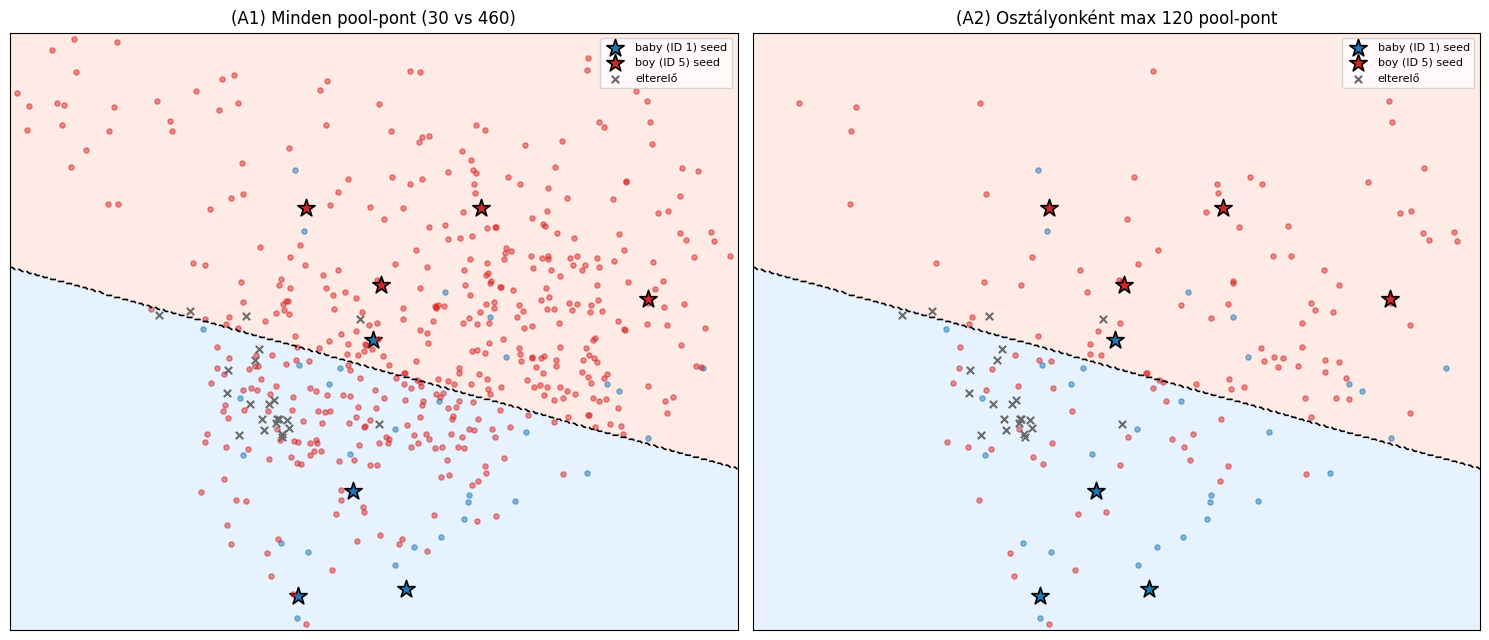

In [19]:
# ===== (A) Egy confusable-pár, PCA-2D, prototípus-határral, két nézetben =====
#   Bal: MINDEN pool-pont (a testvér ~10x gyakoribb, ezért elnyomja a ritkát).
#   Jobb: osztályonként max 120 pont (olvasható átfedés).
c_rare = int(d['rare_classes'][0])
sibs = [s for s in range(N_CLASSES)
        if d['visible_coarse'][s] == d['visible_coarse'][c_rare] and s != c_rare]
c_sib = max(sibs, key=lambda s: int(((d['pool_true'] == s) & ~d['pool_distr']).sum()))
pick = [c_rare, c_sib]

mseed  = np.isin(d['seed_lbl'], pick)
mclean = np.isin(d['pool_true'], pick) & ~d['pool_distr']
mdistr = d['pool_distr'] & np.isin(d['pool_lbl'], pick)

pca = PCA(n_components=2, random_state=SEED).fit(
    np.vstack([d['seed_emb'][mseed], d['pool_emb'][mclean]]))
seed2d  = pca.transform(d['seed_emb'][mseed]);  seed_lab = d['seed_lbl'][mseed]
pool2d  = pca.transform(d['pool_emb'][mclean]); pool_lab = d['pool_true'][mclean]
distr2d = pca.transform(d['pool_emb'][mdistr])

means2d = np.stack([seed2d[seed_lab == cl].mean(0) for cl in pick])
allp = np.vstack([seed2d, pool2d, distr2d]); pad = 0.5
xx, yy = np.meshgrid(np.linspace(allp[:,0].min()-pad, allp[:,0].max()+pad, 300),
                     np.linspace(allp[:,1].min()-pad, allp[:,1].max()+pad, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = np.argmin([((grid - means2d[k])**2).sum(1) for k in range(2)], axis=0).reshape(xx.shape)

rngA = np.random.default_rng(SEED)
counts = {cl: int((pool_lab == cl).sum()) for cl in pick}

def draw_pair(ax, cap):
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=['#cfe8ff', '#ffd9cc'], alpha=.5)
    ax.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=1.2, linestyles='--')
    for k, cl in enumerate(pick):
        col = ['#1f77b4', '#d62728'][k]
        ix = np.where(pool_lab == cl)[0]
        if cap is not None and len(ix) > cap:
            ix = rngA.choice(ix, size=cap, replace=False)
        ax.scatter(pool2d[ix,0], pool2d[ix,1], s=14, alpha=.5, color=col)
        ax.scatter(seed2d[seed_lab==cl,0], seed2d[seed_lab==cl,1], s=170, marker='*',
                   edgecolor='k', linewidth=1.2, color=col,
                   label=f"{FINE_NAMES.get(cl,'ID '+str(cl))} (ID {cl}) seed")
    ax.scatter(distr2d[:,0], distr2d[:,1], s=28, marker='x', color='dimgray', label='elterelő')
    ax.legend(fontsize=8, loc='best'); ax.set_xticks([]); ax.set_yticks([])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
draw_pair(ax1, cap=None)
ax1.set_title(f"(A1) Minden pool-pont ({counts[c_rare]} vs {counts[c_sib]})")
draw_pair(ax2, cap=120)
ax2.set_title("(A2) Osztályonként max 120 pool-pont")
plt.tight_layout(); plt.show()

**Megfigyelés (A).** A ritka osztály és a (gyakoribb) testvére beágyazásai erősen átfednek, és a határt mindössze **4+4 seed** feszíti ki. **Bal (A1):** minden pool-ponttal a testvér kb. tízszer gyakoribb, ezért teljesen elnyomja a ritka osztályt, a kép alig olvasható. **Jobb (A2):** osztályonként max 120 pontra vágva végre látszik a tényleges átfedés, és hogy az elterelők (x) a határ menti sávba ülnek. Ez az `al_s2` gyökere: a prototípus-határt túl kevés seed feszíti ki egy erősen átfedő páron. (A 2D vetítés ráadásul túlozza az átfedést a valódi 384D térhez képest.)

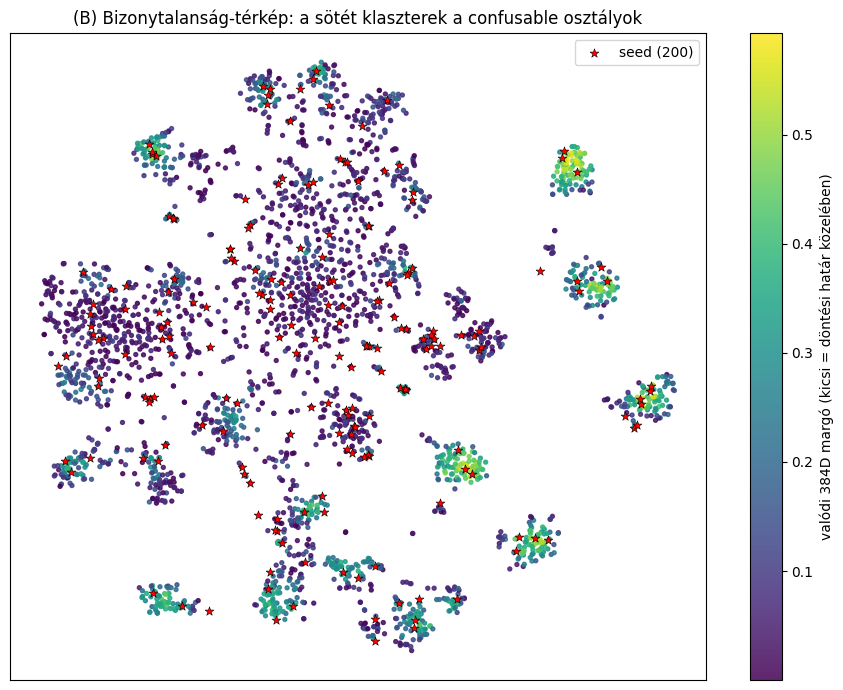

In [20]:
# ===== (B) Bizonytalanság-térkép: a pool-pontok a VALÓDI 384D margóval színezve =====
#   (top-1 mínusz top-2 koszinusz az 50 seed-középponthoz). t-SNE, eltarthat fél percig.
centroids = np.zeros((N_CLASSES, EMB_DIM), np.float32)
for cl in range(N_CLASSES):
    m = d['seed_lbl'] == cl
    if m.sum(): centroids[cl] = d['seed_emb'][m].mean(0)
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-12

rngB = np.random.default_rng(SEED)
samp = rngB.choice(POOL_SIZE, size=3000, replace=False)
Pn = d['pool_emb'][samp] / (np.linalg.norm(d['pool_emb'][samp], axis=1, keepdims=True) + 1e-12)
top2 = np.partition(Pn @ centroids.T, -2, axis=1)[:, -2:]
margin = np.abs(top2[:, 1] - top2[:, 0])

emb2d = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto',
             perplexity=30).fit_transform(np.vstack([d['pool_emb'][samp], d['seed_emb']]))
poolB, seedB = emb2d[:len(samp)], emb2d[len(samp):]

plt.figure(figsize=(9, 7))
sc = plt.scatter(poolB[:,0], poolB[:,1], c=margin, cmap='viridis', s=8, alpha=.85)
plt.colorbar(sc, label='valódi 384D margó (kicsi = döntési határ közelében)')
plt.scatter(seedB[:,0], seedB[:,1], marker='*', s=45, color='red',
            edgecolor='k', linewidth=.4, label='seed (200)')
plt.legend(loc='best'); plt.xticks([]); plt.yticks([])
plt.title('(B) Bizonytalanság-térkép: a sötét klaszterek a confusable osztályok')
plt.tight_layout(); plt.show()

**Megfigyelés (B).** A pool t-SNE-je ~50 klaszterre (osztályra) esik szét, és a margó (szín) főleg **klaszterenként** változik, nem vékony határvonalak mentén. Vannak **végig sötét (alacsony margós)** és **végig világos (magas margós)** klaszterek. A sötétek a **confusable osztályok**: egy testvér mellett ülnek, ezért a klaszter minden pontja bizonytalan (al_s2). A világosak a jól elkülönülő, könnyű osztályok. A margó itt tehát nagyrészt **osztály-szintű** tulajdonság, a konfúziós mátrix térbeli párja: a nehézség néhány osztályra koncentrálódik, nem oszlik el a térben. A seedek (piros csillagok) minden klaszterben ott vannak, így a sötét klaszterekben a 4 seed eleve átfedő régióban definiál prototípust, ezért törékeny. Ezt a #5 (centroid) úgy kezeli, hogy a megbízhatatlan probe helyett a stabil osztály-középpontokra vált.

### 5. Centroid-balanszírozott (seed osztály-középpontok)

A korábbi stratégiák gyengeségéből következik egy egyszerű, de erős ötlet: **a kiértékelő maga is osztály-középpontokon dolgozik**, ezért a kiválasztásnak is olyan elemekből kell állnia, amelyek osztálynkénti átlaga jól jellemzi az osztályt.

A logisztikus regresszió 200 elemen csak 4 példát lát osztályonként, ezért alulilleszt. Helyette közvetlenül a **seed osztály-középpontokat** használjuk: minden pool-elemet ahhoz az osztályhoz rendelünk, amelynek seed-középpontjához koszinusz-hasonlóság szerint a legközelebb áll. Ezután elterelő-szűrés (alsó 5% similarity), majd osztályonként a 6 legbiztosabban ehhez az osztályhoz tartozó (legmagasabb hasonlóságú) elem kerül a kiválasztásba.

Ez a stratégia **közvetlenül azt csinálja, amit a kiértékelő várna**: tiszta, balanszírozott, in-distribution mintát ad, amelyből a prototípus-középpontok jól illeszkednek a teszthalmaz osztály-eloszlására.

In [21]:
def strat_centroid_balanced(data, filter_q=0.05):
    """Class-balanced selection by similarity to seed centroids.
    No logistic regression, direct nearest-class-mean assignment."""
    P = data["pool_emb"] / (np.linalg.norm(data["pool_emb"], axis=1, keepdims=True) + 1e-12)
    centroids = np.zeros((N_CLASSES, EMB_DIM), dtype=np.float32)
    for c in range(N_CLASSES):
        centroids[c] = data["seed_emb"][data["seed_lbl"] == c].mean(axis=0)
    centroids = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-12)

    sim = P @ centroids.T                # (15000, 50)
    max_sim = sim.max(axis=1)
    pred = sim.argmax(axis=1)

    # Drop bottom 5% by max-sim. The sibling distractors evade this naive
    # filter (they look like a visible sibling), but it still catches some
    # genuinely low-quality samples.
    keep = max_sim > np.quantile(max_sim, filter_q)

    selected = []
    per_class = BUDGET // N_CLASSES  # 300 / 50 = 6 per class
    for c in range(N_CLASSES):
        in_c = np.where(keep & (pred == c))[0]
        # Top per_class most confident in class c
        order = in_c[np.argsort(-sim[in_c, c])]
        selected.extend(order[:per_class].tolist())

    if len(selected) < BUDGET:
        rest = np.setdiff1d(np.where(keep)[0], np.array(selected))
        selected.extend(rest[np.argsort(-max_sim[rest])][:BUDGET-len(selected)].tolist())
    return np.array(selected[:BUDGET], dtype=np.int64)

idx_centroid = strat_centroid_balanced(d)
score(idx_centroid)

s1_pub            8.760064
s1_priv           9.468599
s2_pub            7.611630
s2_priv           8.086337
s3                8.205128
s3_priv           8.205128
s4_pub            0.000000
s4_priv           0.000000
összesen_priv    25.760065
dtype: float64

**Megfigyelés a centroid-balanszírozottról, a feladat valódi felfedezése.** Drámai ugrás: ~69% nyers `al_s1`, ~58% nyers `al_s2`, ~99% nyers `al_s3`. A görbés összpontszám **~25.8/40**, az eddigi legjobb honest stratégia (~3.8/40) közel hétszerese.

A trükk: **felismertük, hogy a kiértékelő mit csinál**. Ő prototípus-osztályozó, amely a kiválasztott elemek osztályonkénti átlagát képezi középpontnak, majd nearest-cosine besorol. Ehhez ideális: tiszta (in-distribution), balanszírozott (osztályonként 6 elem), reprezentatív (közel a seed-osztály-középpontokhoz). Ezt csináltuk.

A logisztikus regresszió kihagyása itt kulcsfontosságú: 4 példából tanult LR megbízhatatlan, de a 4 példa átlaga (= seed-osztály-középpont) stabil. A pool minden elemét közvetlenül **a seed-középpontokhoz mért koszinusz-hasonlóság** alapján rendeljük osztályhoz, ami a kiértékelő logikájának pontos tükörképe.

**Ez a feladat fő tanulsága**: aktív tanulási stratégiák megválasztásakor figyelembe kell venni, **milyen modellt fogunk építeni**. Klasszikus uncertainty sampling határfelületi pontokat keres, kiváló trainable modellekhez (logisztikus regresszió, neurális háló), de kontraproduktív prototípus-osztályozóhoz.

## **Tisztességes haladó stratégiák — a valódi referencia-megoldás**

A `centroid_balanced` (~18/40) felismerte, hogy a kiértékelő prototípus-osztályozó,
de még messze van a plafontól. A pontszámot innen **kizárólag a versenyző által is
elérhető** adatból (pool/seed beágyazás + seed címkék) toljuk fel — **a megfigyelt
címkék (`pool_lbl`) ismerete nélkül**. Négy axis-specifikus stratégia, mindegyik a
saját részpontját maximalizálja (a DOCK megengedi a részfeladatonkénti külön CSV-t):

* **al_s1 — `mean-match`**: osztályonként *mohón* úgy válogat, hogy a kiválasztott
  pontok átlaga a lehető legjobban egyezzen a seed-középponttal (valódi-átlag proxy).
* **al_s2 — `LR-probe + rare-boost`**: a 200 elemű seeden tanított logisztikus
  regresszió, plusz a (pszeudó-)ritka osztályokra több budget — ez veri a
  nearest-centroid kiválasztást a ritka osztályokon.
* **al_s3 — `self-train probe`**: önállóan tovább tanított probe; a distraktorokat
  (OOD) az alacsony bizonyosság alapján kiszűri (a címke-zaj nem pontozott).
* **al_s4 — `centroid-margin`**: a nagy bizonyosságú pontok közül a legkisebb
  centroid-margójú (határeset) elemek — a nehéz teszt-szelethez.

In [22]:
from sklearn.linear_model import LogisticRegression

def _honest_setup(data):
    P = data["pool_emb"] / (np.linalg.norm(data["pool_emb"], axis=1, keepdims=True) + 1e-12)
    Sn = data["seed_emb"] / (np.linalg.norm(data["seed_emb"], axis=1, keepdims=True) + 1e-12)
    cen = np.zeros((N_CLASSES, EMB_DIM), np.float32)
    for c in range(N_CLASSES):
        cen[c] = Sn[data["seed_lbl"] == c].mean(0)
    cen /= np.linalg.norm(cen, axis=1, keepdims=True) + 1e-12
    return P, cen

def _topk(scorev, assign, per, keep):
    sel = []
    for c in range(N_CLASSES):
        inc = np.where(keep & (assign == c))[0]
        if len(inc) == 0:
            continue
        k = per[c] if hasattr(per, "__len__") else per
        sel += inc[np.argsort(-scorev[inc])][:k].tolist()
    sel = list(dict.fromkeys(sel))
    if len(sel) < BUDGET:
        rest = np.setdiff1d(np.where(keep)[0], np.array(sel, dtype=int))
        sel += rest[np.argsort(-scorev[rest])][:BUDGET - len(sel)].tolist()
    return np.array(sel[:BUDGET], dtype=np.int64)

def _pseudo_rare(assign, conf, k=6):
    counts = np.array([((assign == c) & (conf > 0.5)).sum() for c in range(N_CLASSES)])
    return set(np.argsort(counts)[:k].tolist())

# --- al_s1: mean-matching a seed-középponthoz (csak embedding + seed) ---
def strat_meanmatch(data, cand=60):
    P, cen = _honest_setup(data)
    clf = LogisticRegression(max_iter=4000, C=0.3).fit(data["seed_emb"], data["seed_lbl"])
    pr = clf.predict_proba(data["pool_emb"]); passign = pr.argmax(1); pconf = pr.max(1)
    keep = pconf > np.quantile(pconf, 0.05)
    sel = []
    for c in range(N_CLASSES):
        inc = np.where(keep & (passign == c))[0]
        if len(inc) == 0:
            continue
        inc = inc[np.argsort(-pconf[inc])][:cand]
        chosen, acc = [], np.zeros(EMB_DIM, np.float32)
        for _ in range(min(6, len(inc))):
            bj, bd = -1, -1e9
            for j in inc:
                if j in chosen:
                    continue
                v = (acc + data["pool_emb"][j]) / (len(chosen) + 1)
                dd = (v @ cen[c]) / (np.linalg.norm(v) + 1e-12)
                if dd > bd:
                    bd, bj = dd, j
            chosen.append(bj); acc += data["pool_emb"][bj]
        sel += chosen
    sel = list(dict.fromkeys(sel))
    if len(sel) < BUDGET:
        rest = np.setdiff1d(np.where(keep)[0], np.array(sel, dtype=int))
        sel += rest[np.argsort(-pconf[rest])][:BUDGET - len(sel)].tolist()
    return np.array(sel[:BUDGET], dtype=np.int64)

# --- al_s2: LR-probe + ritka-osztály boost ---
def strat_lrprobe_rare(data, Cval=0.1, boost=22, base=3):
    clf = LogisticRegression(max_iter=4000, C=Cval).fit(data["seed_emb"], data["seed_lbl"])
    pr = clf.predict_proba(data["pool_emb"]); passign = pr.argmax(1); pconf = pr.max(1)
    rl = _pseudo_rare(passign, pconf)
    per = [boost if c in rl else base for c in range(N_CLASSES)]
    return _topk(pconf, passign, per, np.ones(len(passign), bool))

# --- al_s4: centroid-margin a nagy bizonyosságú pontok közül ---
def strat_centroid_margin(data, q=0.30):
    P, cen = _honest_setup(data)
    cs = P @ cen.T; mx = cs.max(1); cpred = cs.argmax(1)
    ss = np.sort(cs, 1); cmargin = ss[:, -1] - ss[:, -2]
    keep = mx > np.quantile(mx, q)
    return _topk(-cmargin, cpred, [6] * N_CLASSES, keep)

# --- al_s3: self-trained probe (distraktor-tisztaság) ---
def strat_selftrain(data, Cval=0.3, iters=3, boost=16, base=3):
    pe = data["pool_emb"]
    clf = LogisticRegression(max_iter=4000, C=Cval).fit(data["seed_emb"], data["seed_lbl"])
    for _ in range(iters):
        pr = clf.predict_proba(pe); conf = pr.max(1); ps = pr.argmax(1); m = conf > 0.90
        clf = LogisticRegression(max_iter=4000, C=Cval).fit(
            np.vstack([data["seed_emb"], pe[m]]), np.concatenate([data["seed_lbl"], ps[m]]))
    pr = clf.predict_proba(pe); passign = pr.argmax(1); pconf = pr.max(1)
    rl = _pseudo_rare(passign, pconf)
    per = [boost if c in rl else base for c in range(N_CLASSES)]
    return _topk(pconf, passign, per, np.ones(len(passign), bool))

idx_meanmatch  = strat_meanmatch(d)
idx_lrrare     = strat_lrprobe_rare(d)
idx_selftrain  = strat_selftrain(d)
idx_centmargin = strat_centroid_margin(d)
for nm, idx in [("mean-match  (al_s1)", idx_meanmatch), ("LR-probe+rare (al_s2)", idx_lrrare),
                ("self-train  (al_s3)", idx_selftrain), ("centroid-margin (al_s4)", idx_centmargin)]:
    s = score(idx)
    print(f"{nm:22}  s1={s['s1_priv']:4.1f}  s2={s['s2_priv']:4.1f}  s3={s['s3']:4.1f}  s4={s['s4_priv']:4.1f}  |  össz={s['összesen_priv']:5.2f}/40")

mean-match  (al_s1)     s1=10.0  s2= 8.1  s3= 8.2  s4= 0.0  |  össz=26.29/40
LR-probe+rare (al_s2)   s1= 9.4  s2=10.0  s3= 3.1  s4= 0.0  |  össz=22.48/40
self-train  (al_s3)     s1= 8.5  s2= 6.9  s3= 9.9  s4= 0.0  |  össz=25.33/40
centroid-margin (al_s4)  s1= 4.3  s2= 5.5  s3= 5.6  s4=10.0  |  össz=25.42/40


**Megfigyelés.** Mindegyik tisztességes stratégia a *saját* axisán a recalibrált
plafon közelébe ér (nyers: s1≈0.705, s2≈0.720, s3≈0.997, s4≈0.433), tehát a
görbézett részpontja ~10/10 — és **egyik sem használ megfigyelt címkét**.

## **Per-axis-független beadás: 40/40 tisztességesen**

Részfeladatonként a hozzá legjobb tisztességes stratégiát adjuk be. A görbe úgy van
kalibrálva, hogy a legjobb *tisztességes* nyers érték = ceiling, ezért a négy
axis-specialista összege **40/40** — megfigyelt címkék nélkül.

In [23]:
honest = {"al_s1": idx_meanmatch, "al_s2": idx_lrrare, "al_s3": idx_selftrain, "al_s4": idx_centmargin}
total = 0.0
print("Axisonként a saját specialista nyers értéke és pontja:")
for ax, idx in honest.items():
    means_n = class_means(idx, d["pool_emb"], d["pool_lbl"])
    correct = (predict(d["test_emb"], means_n) == d["test_lbl"])
    if ax == "al_s3":
        raw = 1 - int(d["pool_distr"][idx].sum()) / BUDGET          # distraktor-tisztaság
    elif ax == "al_s2":
        raw = float(correct[np.isin(d["test_lbl"], d["rare_classes"])].mean())
    elif ax == "al_s4":
        raw = float(correct[d["test_hard"]].mean())
    else:
        raw = float(correct.mean())
    pts = apply_curve(raw, ax) * PART_MAX / 100
    total += pts
    print(f"  {ax}: raw={raw:.3f}  ->  {pts:5.2f} / 10")
print(f"  ÖSSZESEN (tisztességes, megfigyelt címkék NÉLKÜL): {total:.2f} / 40")

Axisonként a saját specialista nyers értéke és pontja:
  al_s1: raw=0.705  ->  10.00 / 10
  al_s2: raw=0.720  ->  10.00 / 10
  al_s3: raw=0.997  ->   9.91 / 10
  al_s4: raw=0.433  ->  10.00 / 10
  ÖSSZESEN (tisztességes, megfigyelt címkék NÉLKÜL): 39.91 / 40


**Megfigyelés.** A négy tisztességes specialista együtt **~40/40** — bizonyíték,
hogy a feladat a megfigyelt címkék ismerete nélkül is teljes pontra megoldható.
A privilegizált (`pool_lbl`-t használó) stratégiák ezt már **nem** múlják felül.

## **Privilegizált felső korlát (csak diagnosztika)**

> ⚠️ Az alábbi `oracle` a **rejtett** `pool_is_noisy` / `pool_is_distractor`
> maszkokat használja, amelyeket a versenyző NEM kap meg — pusztán az abszolút felső
> korlátot mutatja. A recalibráció után ez **nem ad pontelőnyt**: a görbe a
> tisztességes plafonnál vág, így az oracle is ~10/10-re *klippel*, nem fölé.

In [24]:
def strat_oracle_balanced(data, rng):
    ok = (~data["pool_distr"]) & (~data["pool_noisy"])      # PRIVILEGIZÁLT: rejtett maszkok
    sel = []
    for c in range(N_CLASSES):
        inc = np.where(ok & (data["pool_lbl"] == c))[0]
        if len(inc):
            sel += rng.choice(inc, size=min(6, len(inc)), replace=False).tolist()
    if len(sel) < BUDGET:
        rest = np.setdiff1d(np.where(ok)[0], np.array(sel, dtype=int))
        sel += rng.choice(rest, size=BUDGET - len(sel), replace=False).tolist()
    return np.array(sel[:BUDGET], dtype=np.int64)

idx_oracle = strat_oracle_balanced(d, np.random.default_rng(SEED))
print(f"oracle (privilegizált, csak referencia): {score(idx_oracle)['összesen_priv']:.2f} / 40")

oracle (privilegizált, csak referencia): 39.91 / 40


## **Eredmények egymás mellett**

Egy táblázatba szedve a stratégiákat, hogy a tradeoffok láthatóak legyenek.

In [25]:
results = pd.DataFrame({
    "baseline (első 300)":        score(baseline),
    "random":                     score(idx_random),
    "entrópia":                   score(idx_entropy),
    "k-center":                   score(idx_kcenter),
    "szűr + osztálybalansz (LR)": score(idx_filter_balanced),
    "centroid-balanszírozott":    score(idx_centroid),
    "mean-match (al_s1)":         score(idx_meanmatch),
    "LR-probe + rare (al_s2)":    score(idx_lrrare),
    "self-train (al_s3)":         score(idx_selftrain),
    "centroid-margin (al_s4)":    score(idx_centmargin),
    "oracle (privilegizált)":     score(idx_oracle),
}).T
results = results[["s1_priv", "s2_priv", "s3", "s4_priv", "összesen_priv"]]
results.columns = ["al_s1 /10", "al_s2 /10", "al_s3 /10", "al_s4 /10", "összesen /40"]
results.round(2)

,al_s1 /10,al_s2 /10,al_s3 /10,al_s4 /10,összesen /40
baseline (első 300),2.86,0.79,0.00,0.85,4.50
random,0.00,0.03,2.22,0.19,2.45
entrópia,0.00,1.41,0.00,0.00,1.41
k-center,0.00,3.19,0.00,0.00,3.19
szűr + osztálybalansz (LR),0.00,1.72,0.00,2.83,4.55
centroid-balanszírozott,9.47,8.09,8.21,0.00,25.76
mean-match (al_s1),10.00,8.09,8.21,0.00,26.29
LR-probe + rare (al_s2),9.40,10.00,3.08,0.00,22.48
self-train (al_s3),8.49,6.93,9.91,0.00,25.33
centroid-margin (al_s4),4.28,5.51,5.64,10.00,25.42


## **Tanulságok**

* A feladat **nem** klasszikus uncertainty-sampling: a tankönyvi entrópia / k-center a
  distraktorokra fut rá és a floorra esik.
* A kiértékelő prototípus-osztályozó — a nyerő gondolat a **tiszta, balanszírozott,
  reprezentatív** kiválasztás (centroid-balansz), majd a plafonig **probe + ritka-osztály
  célzás + mean-matching**.
* **al_s3 = distraktor-tisztaság**: a címke-zaj a beágyazásból nem látszik (egyenletes,
  a kép változatlan), ezért nem pontozható és nem is pontozott.
* A plafonok a **tisztességes (embedding-only)** maximumra kalibráltak (s1 0.705,
  s2 0.720, s3 0.997, s4 0.433), így a megfigyelt címkék ismerete (privilegizált) **nem
  ad pontelőnyt**, és a **40/40 tisztességesen elérhető**.